In [1]:
from langgraph.graph import END

print(END)

__end__


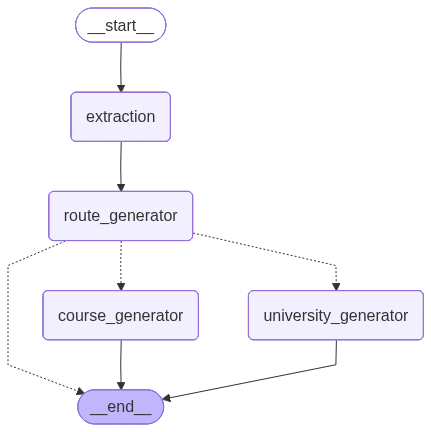

In [1]:
from IPython.display import display, Image

from src.graph import build_graph

graph = build_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
from pprint import pprint
from uuid import uuid4

from dotenv import load_dotenv
from langchain.messages import HumanMessage, AIMessage, AnyMessage
from langchain_core.runnables import RunnableConfig

from src.graph import build_graph
from src.utils import calculate_token_cost

load_dotenv()

graph = build_graph()
config: RunnableConfig = {'configurable': {'thread_id': uuid4()}}

first_msg = AIMessage("""Based on your enquiry, you plan to study the following right?

Course: Business, IT
University: Taylor

or still considering other coure or other uni?""")

token_usage = {'input_tokens': 0, 'output_tokens': 0}

stop_chat = False
sent_first_msg = False


if not sent_first_msg:
    print(f'(AI): {first_msg.content}')
    print()
    
human = HumanMessage(input('(Student): '))
messages: list[AnyMessage] = []
if not sent_first_msg:
    messages = [first_msg, human]
else:
    messages = [human]

stream = graph.stream_events({'messages': messages}, config=config, version='v3')

for message in stream.messages:
    if message.node == 'extraction':
        print(message.output)
    else:
        print('\n(AI):')
        for token in message.text:
            print(token, end='', flush=True)
        print()
        
    if message.output and message.output.usage_metadata:
        usage = message.output.usage_metadata
        token_usage['input_tokens'] = usage['input_tokens'] + token_usage['input_tokens']
        token_usage['output_tokens'] = usage['output_tokens'] + token_usage['output_tokens']

print('\nExtracted info:')
profile = stream.output['student_profile']
pprint(profile.model_dump(), indent=2)
print()
print('\nToken Usage')
print(f'Total input tokens: {token_usage['input_tokens']}')
print(f'Total outpur tokens: {token_usage['output_tokens']}')
print(f'Total costs: RM {calculate_token_cost(token_usage)}')
print()

sent_first_msg = True

(AI): Based on your enquiry, you plan to study the following right?

Course: Business, IT
University: Taylor

or still considering other coure or other uni?



d:\Coding\langchain_project\.venv\Lib\site-packages\langgraph\pregel\main.py:3675: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
d:\Coding\langchain_project\.venv\Lib\site-packages\langgraph\pregel\main.py:3525: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


content=[{'type': 'text', 'text': '{\n  "course_detail": {\n    "can_narrow": true\n  }\n}', 'index': 0, 'extras': {'signature': 'EjQKMgEMOdbHKMCCFIjjKTsld77869C7NZcj2OBUWAim4xRk9YZsWOlPIhsx2Snp9aJtGIsv'}}] additional_kwargs={} response_metadata={'model_provider': 'google_genai', 'safety_ratings': [], 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'output_version': 'v1'} id='lc_run--019e7d3e-0e86-73b3-8094-7d3d25ba8c68' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 530, 'output_tokens': 22, 'total_tokens': 552}


KeyError: 'course_route_state is missing'

In [6]:
from langgraph.graph import MessagesState, StateGraph, START
from langchain.messages import HumanMessage, AIMessage

class TestState(MessagesState, total=False):
    foo: str

def test_node_1(state: MessagesState) -> TestState:
    return {'messages': [AIMessage('This is node_1')]}

def test_node_2(state: MessagesState) -> TestState:
    return {'messages': [AIMessage('This is node_2')], 'foo': 'node_2'}

test_graph = (
    StateGraph(TestState)
    .add_node('node_1', test_node_1)
    .add_node('node_2', test_node_2)
    .add_edge(START, 'node_1')
    .add_edge('node_1', 'node_2')
    .compile()
)

In [7]:
stream = test_graph.stream_events({'messages': [HumanMessage('Hi')]}, version='v3')

for value in stream.values:
    pprint(value, indent=2)

{ 'messages': [ HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cc281d21-a9e9-4715-bc91-fff97bca6cce')]}
{ 'messages': [ HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cc281d21-a9e9-4715-bc91-fff97bca6cce'),
                AIMessage(content='This is node_1', additional_kwargs={}, response_metadata={}, id='2688c63b-c898-4e41-9230-6ff737aff7b0', tool_calls=[], invalid_tool_calls=[])]}
{ 'foo': 'node_2',
  'messages': [ HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cc281d21-a9e9-4715-bc91-fff97bca6cce'),
                AIMessage(content='This is node_1', additional_kwargs={}, response_metadata={}, id='2688c63b-c898-4e41-9230-6ff737aff7b0', tool_calls=[], invalid_tool_calls=[]),
                AIMessage(content='This is node_2', additional_kwargs={}, response_metadata={}, id='e0154b2b-6caf-4b14-9ef7-64d1423bc4d2', tool_calls=[], invalid_tool_calls=[])]}


In [9]:
from src.schemas import StudentProfile
from src.prompt_builder import PromptBuilder

from IPython.display import display, Markdown

profile = StudentProfile()
builder = PromptBuilder(profile)
prompt = builder.build_prompt('course', 'explore_course')

# display(Markdown(prompt))

In [10]:
profile_json = profile.model_dump_json(exclude_unset=True)
profile_json = 'No profile' if profile_json == '{}' else profile_json
profile_json

'No profile'

In [ ]:
from src.utils import calculate_token_cost

print(f'{calculate_token_cost({'input_tokens': 1000, 'output_tokens': 1000})}')

In [ ]:
from pprint import pprint

from src.state import AgentState, CourseState
from src.schemas import StudentProfile, CourseDetail
from src.nodes.course.route_phase import route_course_phase
from src.nodes.router import route_generator_node

course = CourseDetail(confirmed_course=None, confirmed_pathway='a', shortlisted_courses=[], shortlisted_pathways=[], is_able_to_decide=False)
course_route_state: CourseState = {'indecision_count': 3, 'has_recommend_fallback': True, 'is_stuck': False}

student_profile = StudentProfile(course_detail=course)
state: AgentState = {
    'messages': [],
    'student_profile': student_profile,
    'course_state': course_route_state
}
print(route_generator_node(state))
route_course_phase(state)

Command(goto='university_generator')


Command(update={'course_route_state': {'indecision_count': 4, 'is_stuck': True}}, goto='route_generator')